# DRAM M1 CU CMP — 알고리즘 파이프라인 단계별 실행 노트북

어제 만든 **Excel 캐시**(`pre_thk_cache/LC_M1_CU_CMP_M10.xlsx`)와  
샘플 데이터(`merge_df_sample.csv`)를 사용해 각 단계를 개별적으로 실행하고 결과를 시각화합니다.

```
실행 순서
──────────────────────────────────────────
① 환경 설정 & 데이터 로드
② [STEP 0] merge_df 탐색 (데이터 분포)
③ [STEP 1] Pre_Thk_VM — 엑셀에서 결과 로드 + 시각화
④ [STEP 2] Removal Rate — 계산 실행 + 시각화
⑤ [STEP 3] Offset — 계산 실행 + 시각화
⑥ [STEP 4] Alarm 점검
──────────────────────────────────────────
```

---
## 환경 설정
외부 의존성(MongoDB, Cube 메신저, MES HUB)을 Mock으로 대체하고 필요한 라이브러리를 임포트합니다.

In [1]:
import sys, os
from pathlib import Path
from unittest.mock import MagicMock

# ── 경로 설정 ──────────────────────────────────────────────────────
ALGO_DIR = Path('..') / 'algorithm_new'
sys.path.insert(0, str(ALGO_DIR))

# Jupyter 는 async 이벤트 루프 위에서 실행되므로
# Django ORM 동기 쿼리를 허용하도록 설정
os.environ['DJANGO_ALLOW_ASYNC_UNSAFE'] = '1'

# ── 1. MongoClient 전역 Mock ────────────────────────────────────────
import pymongo as _pymongo

_mock_collection = MagicMock()
_mock_collection.find.return_value = iter([])

_mock_db = MagicMock()
_mock_db.__getitem__.return_value = _mock_collection

_mock_client = MagicMock()
_mock_client.__getitem__.return_value = _mock_db
_mock_client.close.return_value = None

_pymongo.MongoClient = MagicMock(return_value=_mock_client)

# ── 2. RR / Offset Mock 준비 ────────────────────────────────────────
import Common.REMOVAL_RATE as _rr_mod
import Common.OFFSET as _offset_mod

# load_pre_thk_data: 내부 Excel 캐시 분기가 이미 구현되어 있으므로 그대로 사용
_rr_mod.Removal_Rate_Get._original_load_pre_thk = staticmethod(
    _rr_mod.Removal_Rate_Get.load_pre_thk_data
)

# load_rr_data: MongoDB RR 컬렉션 우회 → 가상 B1/B0 삽입
def _mock_load_rr_data(merge_df, Fab, Lot_Code, Oper_Desc, APC_Para_List, mongo_url, mongo_db):
    out = merge_df.copy()
    for para in APC_Para_List:
        out[f'{para}_B1'] = 0.80
        out[f'{para}_B0'] = 5.00
    print(f'    [mock] load_rr_data: B1=0.80, B0=5.00  (APC: {list(APC_Para_List)})')
    return out

_offset_mod.OFFSET_Get.load_rr_data = staticmethod(_mock_load_rr_data)

# ── 3. 공통 라이브러리 ───────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

try:
    matplotlib.rc('font', family='AppleGothic')   # macOS 한글 폰트
except:
    pass
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

print('✅ 환경 설정 완료')

✅ 환경 설정 완료


---
## 기본 데이터 로드
Django DB에서 Set-up 정보를 읽고, 샘플 CSV로 CMP 실측 데이터를 로드합니다.

In [2]:
from Common.Get_Data import Get_data
from Common.MongoDB_Control import _STORE   # 인메모리 저장소 (결과 확인용)

FAMILY    = 'DRAM'
OPER_DESC = 'M1 CU CMP'
POL_TYPE  = 3

# ── Set-up 정보 로드 (Django DB) ────────────────────────────────────
mico_info_table = Get_data.baseinfoGetData(Family=FAMILY, oper_desc=OPER_DESC)
mico_info_table['Group_Name'] = mico_info_table['Group_Name'].fillna('not_group')
mico_info_table['for_key_list'] = (
    mico_info_table['Lot_Code'] + '_' +
    mico_info_table['Oper_Code'] + '_' +
    mico_info_table['Fab']
)

print(f'Set-up 키 목록 ({len(mico_info_table["for_key_list"].unique())}개):')
for k in mico_info_table['for_key_list'].unique():
    grp = mico_info_table[mico_info_table['for_key_list'] == k]['Group_Name'].iloc[0]
    print(f'  {k}  ({grp})')

print()
print('주요 Set-up 컬럼:')
display(mico_info_table[[
    'Lot_Code','Fab','Maker','Recipe_ID','APC_Para','Thk_Para',
    'FB_Type','Pre_Thk_Period','Target','Pre_Target'
]].drop_duplicates())

Set-up 키 목록 (1개):
  LC_V5077000E_M10  (not_group)

주요 Set-up 컬럼:


,Lot_Code,Fab,Maker,Recipe_ID,APC_Para,Thk_Para,FB_Type,Pre_Thk_Period,Target,Pre_Target
0,LC,M10,AMAT,E2_M1CU_R12_TSV.CAS,P3,AMAT_POST_OCD_AVG,TIME,3,1900,2350


In [3]:
# ── CMP 실측 데이터 로드 (CSV) ───────────────────────────────────────
merge_df = pd.read_csv(
    ALGO_DIR / 'merge_df_sample.csv',
    parse_dates=['Date', 'pre_oper_time']
)
merge_df['IDLE'] = merge_df['IDLE'].fillna('')

print(f'merge_df: {merge_df.shape[0]:,}행 × {merge_df.shape[1]}열')
print(f'기간: {merge_df["Date"].min().date()} ~ {merge_df["Date"].max().date()}')
print(f'장비: {sorted(merge_df["eqp_id"].unique())}')
print(f'레시피: {sorted(merge_df["recipe_id"].unique())}')
merge_df.head(3)

merge_df: 20,844행 × 51열
기간: 2026-04-15 ~ 2026-05-15
장비: ['KCMP41', 'KCMP42', 'KCMP43', 'KCMP44', 'KCMP45']
레시피: ['E2_M1CU_R12_OD.CAS', 'E2_M1CU_R12_TSV.CAS', 'E2_M1CU_R13_OD.CAS', 'E2_M1CU_R13_TSV.CAS']


,Date,process_id,recipe_id,eqp_id,eqp_model,operation_id,oper_id,oper_det_desc,item_name,r2r_rank,...,AMAT_POST_OCD_Z2_AVG,AMAT_POST_OCD_Z3_AVG,AMAT_POST_OCD_Z4_AVG,AMAT_POST_OCD_Z5_AVG,IDLE,rank,event_tm,before_recipe_id,brfore_info,substrate_id
0,2026-04-15 00:00:00,F_6E2_01,E2_M1CU_R13_OD.CAS,KCMP42,REFLEXION_LK,V5077000E,V5077000E,M1 CU CMP,FORMULA,1,...,1948.55,1949.52,1931.80,1972.33,Idle_1,1,-,-,-,LOT0000_01
1,2026-04-15 00:00:16,F_6E2_01,E2_M1CU_R13_TSV.CAS,KCMP43,REFLEXION_LK,V5077000E,V5077000E,M1 CU CMP,FORMULA,1,...,1886.36,1867.38,1935.87,1956.40,Idle_1,1,-,-,-,LOT0000_02
2,2026-04-15 00:00:39,F_6E2_01,E2_M1CU_R12_OD.CAS,KCMP45,REFLEXION_LK,V5077000E,V5077000E,M1 CU CMP,FORMULA,1,...,1852.01,1852.21,1884.22,1892.68,Idle_1,1,-,-,-,LOT0000_03


---
## STEP 0 — merge_df 데이터 분포 탐색
CMP 실측 데이터의 장비별·날짜별 분포와 주요 측정값 트렌드를 확인합니다.

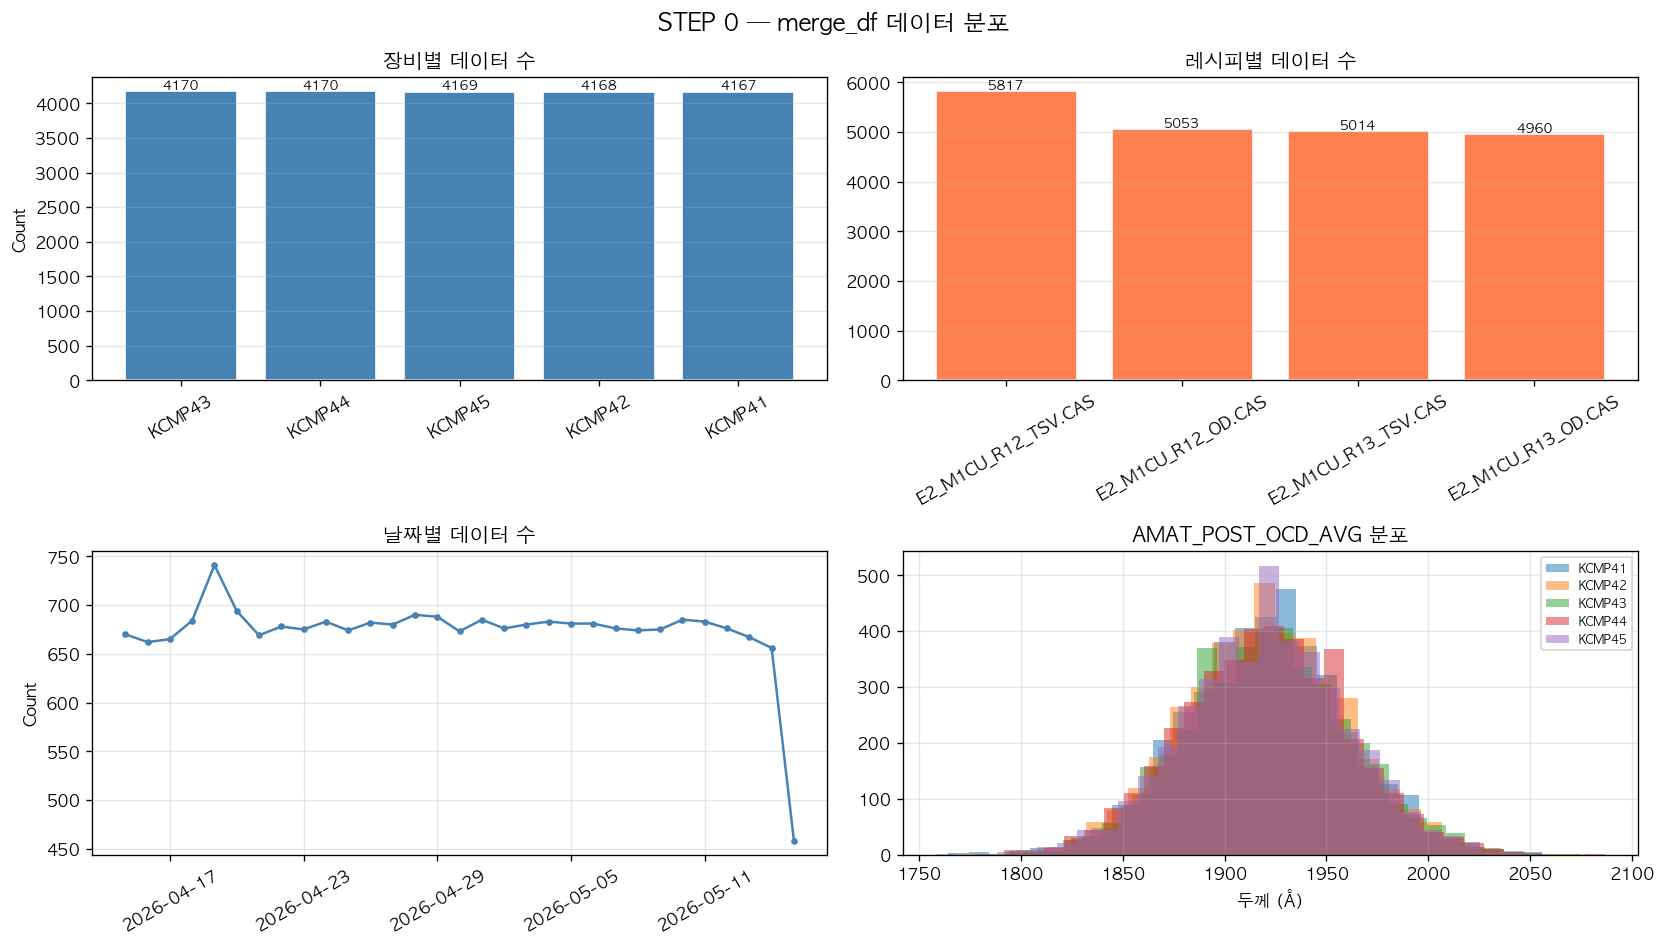

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('STEP 0 — merge_df 데이터 분포', fontsize=14, fontweight='bold')

# ① 장비별 데이터 수
ax = axes[0, 0]
cnt_eqp = merge_df.groupby('eqp_id').size().sort_values(ascending=False)
bars = ax.bar(cnt_eqp.index, cnt_eqp.values, color='steelblue', edgecolor='white')
ax.bar_label(bars, fmt='%d', fontsize=8)
ax.set_title('장비별 데이터 수')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.3)

# ② 레시피별 데이터 수
ax = axes[0, 1]
cnt_rcp = merge_df.groupby('recipe_id').size().sort_values(ascending=False)
bars = ax.bar(cnt_rcp.index, cnt_rcp.values, color='coral', edgecolor='white')
ax.bar_label(bars, fmt='%d', fontsize=8)
ax.set_title('레시피별 데이터 수')
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.3)

# ③ 날짜별 데이터 수 (일별)
ax = axes[1, 0]
cnt_date = merge_df.groupby(merge_df['Date'].dt.date).size()
ax.plot(cnt_date.index, cnt_date.values, marker='o', markersize=3, color='steelblue')
ax.set_title('날짜별 데이터 수')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)
ax.xaxis.set_major_locator(ticker.MaxNLocator(6))
ax.grid(alpha=0.3)

# ④ Post OCD AVG 분포 (장비별 histogram)
ax = axes[1, 1]
thk_col = 'AMAT_POST_OCD_AVG'
if thk_col in merge_df.columns:
    colors_hist = plt.cm.tab10.colors
    for i, eqp in enumerate(sorted(merge_df['eqp_id'].unique())):
        vals = merge_df[merge_df['eqp_id'] == eqp][thk_col].dropna()
        ax.hist(vals, bins=30, alpha=0.5, label=eqp, color=colors_hist[i])
    ax.set_title(f'{thk_col} 분포')
    ax.set_xlabel('두께 (Å)')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

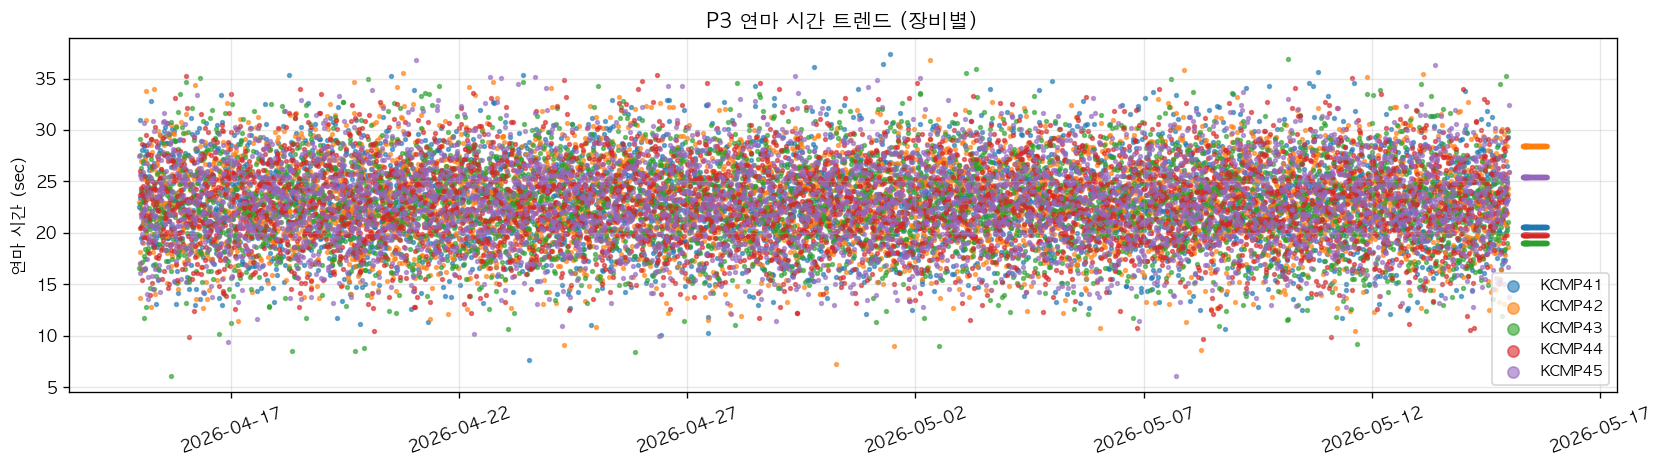

In [5]:
# 연마 시간(P3) 트렌드 — 장비별
pol_col = 'P3'
if pol_col in merge_df.columns:
    fig, ax = plt.subplots(figsize=(14, 4))
    colors_t = plt.cm.tab10.colors
    for i, eqp in enumerate(sorted(merge_df['eqp_id'].unique())):
        sub = merge_df[merge_df['eqp_id'] == eqp].sort_values('Date')
        ax.scatter(sub['Date'], sub[pol_col], label=eqp, s=5,
                   color=colors_t[i % len(colors_t)], alpha=0.6)
    ax.set_title(f'{pol_col} 연마 시간 트렌드 (장비별)', fontsize=12, fontweight='bold')
    ax.set_ylabel('연마 시간 (sec)')
    ax.legend(markerscale=3, fontsize=9)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(8))
    ax.grid(alpha=0.3)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

---
## STEP 1 — Pre_Thk_VM (전두께 가상계측)

전공정 계측값으로 CMP 투입 전 두께를 예측합니다.  
어제 생성된 **Excel 캐시**를 로드하여 결과를 시각화합니다.

> **캐시 파일**: `pre_thk_cache/LC_M1_CU_CMP_M10.xlsx`

In [6]:
# ── Pre_Thk_VM 엑셀 캐시 로드 ────────────────────────────────────────
CACHE_DIR  = ALGO_DIR / 'pre_thk_cache'
cache_file = CACHE_DIR / 'LC_M1_CU_CMP_M10.xlsx'

if cache_file.exists():
    pre_thk_df = pd.read_excel(cache_file)
    print(f'✅ 엑셀 캐시 로드: {cache_file.name}  ({len(pre_thk_df)}행)')
    display(pre_thk_df)
else:
    pre_thk_df = pd.DataFrame()
    print(f'⚠️  캐시 파일 없음: {cache_file}')
    print('   아래 [재계산] 셀에서 RUN_RECOMPUTE = True 로 바꾸고 실행하세요.')

✅ 엑셀 캐시 로드: LC_M1_CU_CMP_M10.xlsx  (16행)


,pre_oper_time,pre_eq_ch,Pre_Thk,Count,THK_Para,Date,Oper_Code
0,1970-01-01,6KTSD505_1,1.877385,105,AMAT_POST_OCD_AVG,2026-05-15 13:29:52.450,V5077000E
1,1970-01-01,6KTSD506_2,12.267733,111,AMAT_POST_OCD_AVG,2026-05-15 13:29:52.450,V5077000E
2,1970-01-01,6KTSD508_2,-13.874361,113,AMAT_POST_OCD_AVG,2026-05-15 13:29:52.450,V5077000E
3,1970-01-01,6KTSD508_1,3.603075,125,AMAT_POST_OCD_AVG,2026-05-15 13:29:52.450,V5077000E
4,1970-01-01,6KTSD501_1,10.780029,111,AMAT_POST_OCD_AVG,2026-05-15 13:29:52.450,V5077000E
5,1970-01-01,6KTSD502_2,4.273649,114,AMAT_POST_OCD_AVG,2026-05-15 13:29:52.450,V5077000E
6,1970-01-01,6KTSD503_2,-7.492733,119,AMAT_POST_OCD_AVG,2026-05-15 13:29:52.450,V5077000E
7,1970-01-01,6KTSD505_2,-5.510217,133,AMAT_POST_OCD_AVG,2026-05-15 13:29:52.450,V5077000E
8,1970-01-01,6KTSD501_2,-1.258186,108,AMAT_POST_OCD_AVG,2026-05-15 13:29:52.450,V5077000E
9,1970-01-01,6KTSD503_1,-0.536422,100,AMAT_POST_OCD_AVG,2026-05-15 13:29:52.450,V5077000E


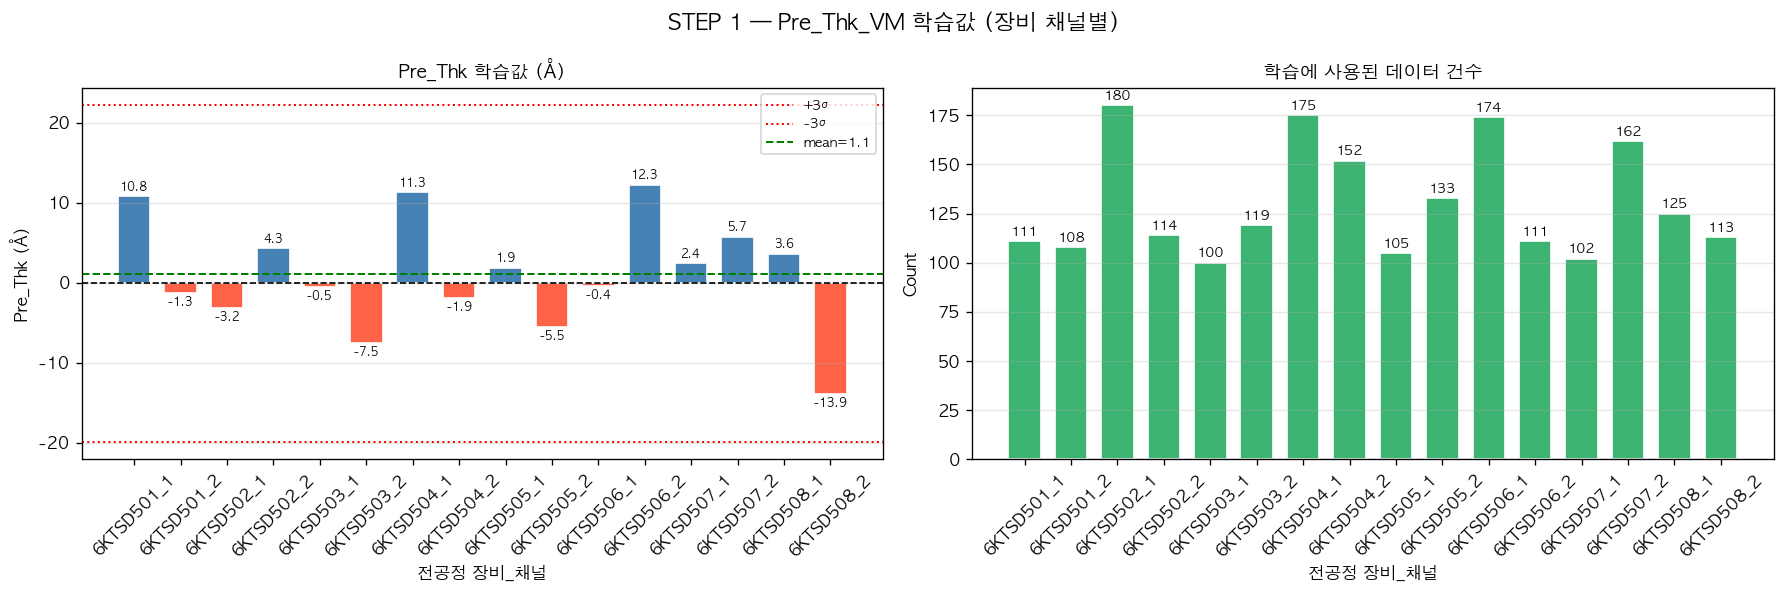


 Pre_Thk 통계
  평균  : 1.14 Å
  표준편차: 7.04 Å
  범위  : -13.87 ~ 12.27 Å


In [7]:
# ── Pre_Thk_VM 시각화 ────────────────────────────────────────────────
if pre_thk_df.empty:
    print('데이터 없음 — 위 셀에서 캐시를 로드하거나 재계산하세요.')
else:
    pre_thk_sorted = pre_thk_df.sort_values('pre_eq_ch')

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle('STEP 1 — Pre_Thk_VM 학습값 (장비 채널별)', fontsize=13, fontweight='bold')

    # ① Pre_Thk 값 — 0 기준 상하 bar
    ax = axes[0]
    colors_pt = ['tomato' if v < 0 else 'steelblue' for v in pre_thk_sorted['Pre_Thk']]
    bars = ax.bar(pre_thk_sorted['pre_eq_ch'], pre_thk_sorted['Pre_Thk'],
                  color=colors_pt, edgecolor='white', width=0.7)
    ax.axhline(0, color='black', linewidth=1, linestyle='--')
    ax.bar_label(bars, fmt='%.1f', fontsize=7, padding=2)

    mean_v = pre_thk_sorted['Pre_Thk'].mean()
    std_v  = pre_thk_sorted['Pre_Thk'].std()
    ax.axhline(mean_v + 3*std_v, color='red',   linewidth=1.2, linestyle=':', label='+3σ')
    ax.axhline(mean_v - 3*std_v, color='red',   linewidth=1.2, linestyle=':', label='-3σ')
    ax.axhline(mean_v,            color='green', linewidth=1.2, linestyle='--', label=f'mean={mean_v:.1f}')
    ax.set_title('Pre_Thk 학습값 (Å)', fontsize=11)
    ax.set_ylabel('Pre_Thk (Å)')
    ax.set_xlabel('전공정 장비_채널')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

    # ② Count — 학습 데이터 건수
    ax = axes[1]
    cnt_col = 'Count' if 'Count' in pre_thk_sorted.columns else None
    if cnt_col:
        bars = ax.bar(pre_thk_sorted['pre_eq_ch'], pre_thk_sorted[cnt_col],
                      color='mediumseagreen', edgecolor='white', width=0.7)
        ax.bar_label(bars, fmt='%d', fontsize=8, padding=2)
        ax.set_title('학습에 사용된 데이터 건수', fontsize=11)
        ax.set_ylabel('Count')
        ax.set_xlabel('전공정 장비_채널')
        ax.tick_params(axis='x', rotation=45)
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f'\n Pre_Thk 통계')
    print(f'  평균  : {pre_thk_df["Pre_Thk"].mean():.2f} Å')
    print(f'  표준편차: {pre_thk_df["Pre_Thk"].std():.2f} Å')
    print(f'  범위  : {pre_thk_df["Pre_Thk"].min():.2f} ~ {pre_thk_df["Pre_Thk"].max():.2f} Å')

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# [선택] Pre_Thk_VM 재계산 — 엑셀 캐시를 새로 생성하고 싶을 때만 실행
# ═══════════════════════════════════════════════════════════════════
RUN_RECOMPUTE = False   # ← True 로 바꾸면 실행

if RUN_RECOMPUTE:
    from Common.Module import Module_Get
    _STORE.clear()
    print('Pre_Thk_VM 재계산 시작...')
    for key_str in mico_info_table['for_key_list'].unique():
        mico_key = mico_info_table[mico_info_table['for_key_list'] == key_str].copy()
        oper_code = mico_key['Oper_Code'].iloc[0]
        merge_filtered = merge_df[merge_df['operation_id'] == oper_code].copy()
        Module_Get.compute_pre_thk_vm(merge_filtered, mico_key, POL_TYPE)
    pre_thk_df = pd.read_excel(cache_file)
    print('✅ 재계산 완료. 위의 시각화 셀을 다시 실행하세요.')

Pre_Thk_VM 재계산 시작...

  [Pre_Thk_VM] M10 | LC | M1 CU CMP 시작
    Thk_Para=AMAT_POST_OCD_AVG | 경로=Detrend+MA
    [MongoDB mock] push_df  → MICO_PRE_THK_LC_M1 CU CMP_M10_Period: 16건 저장
    → Excel 저장: LC_M1_CU_CMP_M10.xlsx
    → 저장 16건
 pre_eq_ch    Pre_Thk  Count
6KTSD505_1   1.877385  105.0
6KTSD506_2  12.267733  111.0
6KTSD508_2 -13.874361  113.0
6KTSD508_1   3.603075  125.0
6KTSD501_1  10.780029  111.0
6KTSD502_2   4.273649  114.0
6KTSD503_2  -7.492733  119.0
6KTSD505_2  -5.510217  133.0
6KTSD501_2  -1.258186  108.0
6KTSD503_1  -0.536422  100.0
6KTSD507_1   2.448200  102.0
6KTSD506_1  -0.361580  174.0
6KTSD504_1  11.332395  175.0
6KTSD507_2   5.729459  162.0
6KTSD502_1  -3.172163  180.0
6KTSD504_2  -1.933554  152.0
  [Pre_Thk_VM] M10 | LC | M1 CU CMP 완료
✅ 재계산 완료. 위의 시각화 셀을 다시 실행하세요.


---
## STEP 2 — Removal Rate

패드 소모에 따른 연마율(Removal Rate) 학습값을 계산합니다.  
Pre_Thk_VM은 Excel 캐시(`pre_thk_cache/`)에서 자동 로드됩니다.

In [10]:
from Common.Module import Module_Get

# ── 이전 RR 결과 초기화 ─────────────────────────────────────────────
for k in [k for k in _STORE if 'Removal_Rate' in k]:
    _STORE[k] = []

# ── Removal Rate 실행 ───────────────────────────────────────────────
for key_str in mico_info_table['for_key_list'].unique():
    mico_key = mico_info_table[mico_info_table['for_key_list'] == key_str].copy()
    oper_code = mico_key['Oper_Code'].iloc[0]
    merge_filtered = merge_df[merge_df['operation_id'] == oper_code].copy()

    grp = mico_key['Group_Name'].iloc[0]
    if grp == 'not_group':
        Module_Get.compute_removal_rate(merge_filtered, mico_key, POL_TYPE)
    else:
        Module_Get.compute_removal_rate_group(merge_filtered, mico_key, POL_TYPE)

print('\n✅ Removal Rate 계산 완료')


  [Removal Rate] M10 | LC | M1 CU CMP 시작
    Pre_Thk_VM 로드 중 ...
    [Excel 캐시] LC_M1_CU_CMP_M10.xlsx 로드
    → AMAT_POST_OCD_AVG_VM: 20844/20844 매칭
    APC_Para=P3 | Recipe_ID=E2_M1CU_R12_TSV.CAS | Thk_Para=AMAT_POST_OCD_AVG
    [MongoDB mock] insert_row → MICO_Removal_Rate_LC_M1 CU CMP_M10: {'EQ': 'KCMP43', 'Recipe_ID': 'E2_M1CU_R12_TSV.CAS', 'Count': 1039, 'b1': '-0.0137', 'b0': '19.8651', 'b1_weighted': '-0.0307', 'b0_weighted': '21.1675', 'if_b1': '0.1797', 'if_b0': '19.7243'}
    [MongoDB mock] insert_row → MICO_Removal_Rate_LC_M1 CU CMP_M10: {'EQ': 'KCMP42', 'Recipe_ID': 'E2_M1CU_R12_TSV.CAS', 'Count': 1046, 'b1': '-0.0112', 'b0': '19.1610', 'if_b1': '0.0880', 'if_b0': '18.6487'}
    [MongoDB mock] insert_row → MICO_Removal_Rate_LC_M1 CU CMP_M10: {'EQ': 'KCMP41', 'Recipe_ID': 'E2_M1CU_R12_TSV.CAS', 'Count': 1010, 'b1': '0.0175', 'b0': '19.5028', 'b1_weighted': '-0.0105', 'b0_weighted': '20.0545'}
    [MongoDB mock] insert_row → MICO_Removal_Rate_LC_M1 CU CMP_M10: {'EQ': 'KCMP44'

In [11]:
# ── RR 결과 수집 ────────────────────────────────────────────────────
rr_result_list = []
for k, records in _STORE.items():
    if 'Removal_Rate' in k and records:
        df_temp = pd.DataFrame(records)
        df_temp['_collection'] = k
        rr_result_list.append(df_temp)

if rr_result_list:
    rr_df = pd.concat(rr_result_list, ignore_index=True)
    rr_df['Date'] = pd.to_datetime(rr_df['Date'])
    # b1/b0를 숫자 타입으로 변환
    for col in ['b1', 'b0', 'b1_weighted', 'b0_weighted', 'if_b1', 'if_b0']:
        if col in rr_df.columns:
            rr_df[col] = pd.to_numeric(rr_df[col], errors='coerce')
    print(f'RR 결과: {len(rr_df)}건')
    display(rr_df.drop(columns=['_collection'], errors='ignore'))
else:
    rr_df = pd.DataFrame()
    print('⚠️  RR 결과 없음 — 위 셀을 먼저 실행하세요.')

RR 결과: 5건


,Date,Fab,Lot_Code,Oper_Code,Oper_Desc,APC_Para,EQ,Recipe_ID,Count,b1,b0,b1_weighted,b0_weighted,if_b1,if_b0
0,2026-05-16 00:13:14.999046,M10,LC,V5077000E,M1 CU CMP,P3,KCMP43,E2_M1CU_R12_TSV.CAS,1039,-0.0137,19.8651,-0.0307,21.1675,0.1797,19.7243
1,2026-05-16 00:13:14.999046,M10,LC,V5077000E,M1 CU CMP,P3,KCMP42,E2_M1CU_R12_TSV.CAS,1046,-0.0112,19.1610,NaN,NaN,0.0880,18.6487
2,2026-05-16 00:13:14.999046,M10,LC,V5077000E,M1 CU CMP,P3,KCMP41,E2_M1CU_R12_TSV.CAS,1010,0.0175,19.5028,-0.0105,20.0545,NaN,NaN
3,2026-05-16 00:13:14.999046,M10,LC,V5077000E,M1 CU CMP,P3,KCMP44,E2_M1CU_R12_TSV.CAS,1049,-0.0104,19.5762,-0.0316,20.1153,0.0808,19.3880
4,2026-05-16 00:13:14.999046,M10,LC,V5077000E,M1 CU CMP,P3,KCMP45,E2_M1CU_R12_TSV.CAS,1053,-0.0277,19.4525,0.0414,17.9843,-0.1070,19.3139


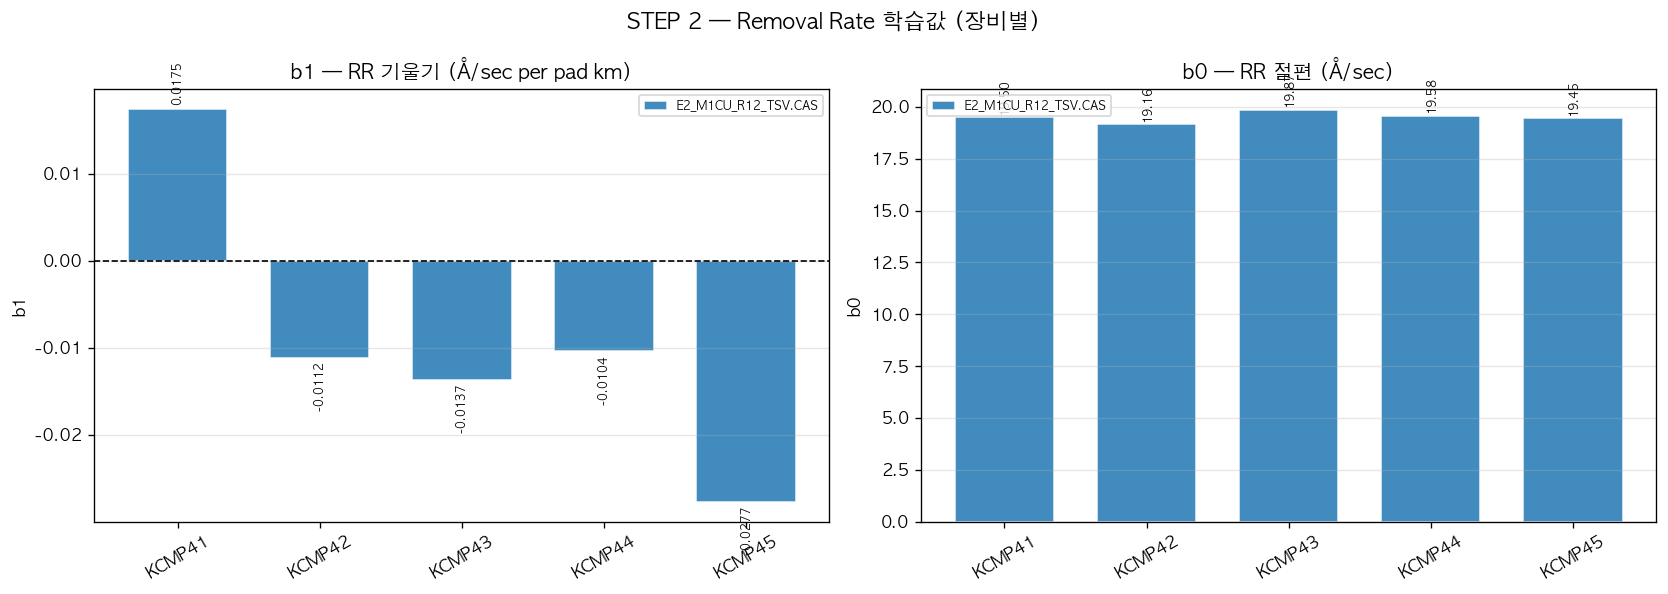

In [12]:
# ── Removal Rate 학습값 시각화 (장비별 b1/b0) ────────────────────────
if not rr_df.empty and 'EQ' in rr_df.columns and 'b1' in rr_df.columns:

    eq_list = sorted(rr_df['EQ'].unique())
    rcp_list = sorted(rr_df['Recipe_ID'].unique()) if 'Recipe_ID' in rr_df.columns else ['N/A']
    colors_rr = plt.cm.tab10.colors

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('STEP 2 — Removal Rate 학습값 (장비별)', fontsize=13, fontweight='bold')

    # ① b1 (기울기) — 장비별 bar
    ax = axes[0]
    x = np.arange(len(eq_list))
    width = 0.7 / max(len(rcp_list), 1)
    for j, rcp in enumerate(rcp_list):
        sub = rr_df[rr_df['Recipe_ID'] == rcp] if 'Recipe_ID' in rr_df.columns else rr_df
        b1_vals = [sub[sub['EQ'] == eq]['b1'].mean() for eq in eq_list]
        bars = ax.bar(x + j * width, b1_vals, width, label=rcp[:25],
                      color=colors_rr[j % len(colors_rr)], edgecolor='white', alpha=0.85)
        ax.bar_label(bars, fmt='%.4f', fontsize=7, rotation=90, padding=2)
    ax.axhline(0, color='black', linewidth=1, linestyle='--')
    ax.set_xticks(x + width * (len(rcp_list) - 1) / 2)
    ax.set_xticklabels(eq_list, rotation=30)
    ax.set_title('b1 — RR 기울기 (Å/sec per pad km)')
    ax.set_ylabel('b1')
    ax.legend(fontsize=7)
    ax.grid(axis='y', alpha=0.3)

    # ② b0 (절편) — 장비별 bar
    ax = axes[1]
    for j, rcp in enumerate(rcp_list):
        sub = rr_df[rr_df['Recipe_ID'] == rcp] if 'Recipe_ID' in rr_df.columns else rr_df
        b0_vals = [sub[sub['EQ'] == eq]['b0'].mean() for eq in eq_list]
        bars = ax.bar(x + j * width, b0_vals, width, label=rcp[:25],
                      color=colors_rr[j % len(colors_rr)], edgecolor='white', alpha=0.85)
        ax.bar_label(bars, fmt='%.2f', fontsize=7, rotation=90, padding=2)
    ax.set_xticks(x + width * (len(rcp_list) - 1) / 2)
    ax.set_xticklabels(eq_list, rotation=30)
    ax.set_title('b0 — RR 절편 (Å/sec)')
    ax.set_ylabel('b0')
    ax.legend(fontsize=7)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

else:
    print('시각화할 RR 데이터 없음 — 위 셀들을 순서대로 실행하세요.')

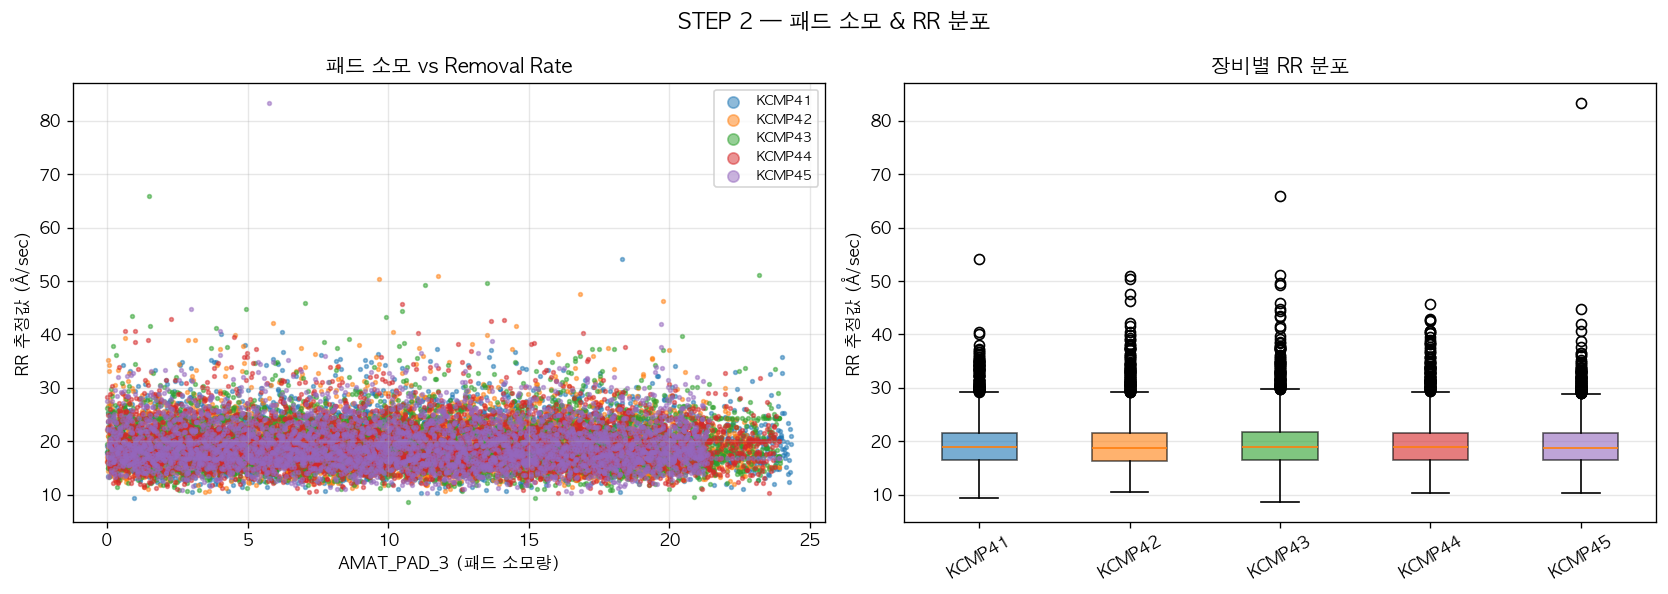

In [13]:
# ── 패드 소모량 vs RR 산점도 + 장비별 분포 ────────────────────────────
pad_col = 'AMAT_PAD_3'
pol_col = 'P3'
thk_col = 'AMAT_POST_OCD_AVG'

if all(c in merge_df.columns for c in [pad_col, pol_col, thk_col]):
    pre_target = float(mico_info_table['Pre_Target'].iloc[0]) if 'Pre_Target' in mico_info_table.columns else 3000
    temp = merge_df.copy()
    temp['RR_est'] = (pre_target - temp[thk_col]) / temp[pol_col].replace(0, np.nan)
    temp = temp.dropna(subset=['RR_est', pad_col])
    temp = temp[(temp['RR_est'] > 0) & (temp['RR_est'] < 200)]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('STEP 2 — 패드 소모 & RR 분포', fontsize=13, fontweight='bold')

    # 패드 소모 vs RR 산점도
    ax = axes[0]
    colors_s = plt.cm.tab10.colors
    for i, eqp in enumerate(sorted(temp['eqp_id'].unique())):
        sub = temp[temp['eqp_id'] == eqp]
        ax.scatter(sub[pad_col], sub['RR_est'], s=5, alpha=0.5,
                   color=colors_s[i % len(colors_s)], label=eqp)
    ax.set_xlabel(f'{pad_col} (패드 소모량)')
    ax.set_ylabel('RR 추정값 (Å/sec)')
    ax.set_title('패드 소모 vs Removal Rate')
    ax.legend(markerscale=3, fontsize=8)
    ax.grid(alpha=0.3)

    # 장비별 RR 분포 박스플롯
    ax = axes[1]
    eqp_list_bp = sorted(temp['eqp_id'].unique())
    data_bp = [temp[temp['eqp_id'] == eq]['RR_est'].values for eq in eqp_list_bp]
    bp = ax.boxplot(data_bp, labels=eqp_list_bp, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors_s):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_title('장비별 RR 분포')
    ax.set_ylabel('RR 추정값 (Å/sec)')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

---
## STEP 3 — Offset

Idle/Layer 구간별 연마 시간 보정량(Offset)을 계산합니다.  
RR B1/B0를 사용해 예측 RR과 실측 RR의 차이로 보정량을 산출합니다.

In [14]:
# ── 이전 Offset 결과 초기화 ─────────────────────────────────────────
for k in [k for k in _STORE if 'OFFSET' in k]:
    _STORE[k] = []

# ── Offset 실행 ─────────────────────────────────────────────────────
for key_str in mico_info_table['for_key_list'].unique():
    mico_key = mico_info_table[mico_info_table['for_key_list'] == key_str].copy()
    oper_code = mico_key['Oper_Code'].iloc[0]
    merge_filtered = merge_df[merge_df['operation_id'] == oper_code].copy()
    Module_Get.compute_offset(merge_filtered, mico_key, POL_TYPE)

print('\n✅ Offset 계산 완료')


  [Offset] M10 | LC | M1 CU CMP 시작
    APC_Para 목록: ['P3'] | Offset_Group=Y
    [mock] load_rr_data: B1=0.80, B0=5.00  (APC: ['P3'])
    [MongoDB mock] push_df  → MICO_OFFSET_LC_M1 CU CMP_M10: 20건 저장
    [MongoDB mock] push_df  → MICO_OFFSET_LC_M1 CU CMP_M10: 10건 저장
  [Offset] M10 | LC | M1 CU CMP 완료

✅ Offset 계산 완료


In [15]:
# ── Offset 결과 수집 ────────────────────────────────────────────────
offset_result_list = []
for k, records in _STORE.items():
    if 'OFFSET' in k and records:
        df_temp = pd.DataFrame(records)
        df_temp['_collection'] = k
        offset_result_list.append(df_temp)

if offset_result_list:
    offset_df = pd.concat(offset_result_list, ignore_index=True)
    offset_df['Date'] = pd.to_datetime(offset_df['Date'], errors='coerce')
    print(f'Offset 결과: {len(offset_df)}건')
    display(offset_df.drop(columns=['_collection'], errors='ignore').head(15))
else:
    offset_df = pd.DataFrame()
    print('⚠️  Offset 결과 없음 — 위 셀을 먼저 실행하세요.')

Offset 결과: 30건


,eqp_id,recipe_id,IDLE,OFFSET,APC_Para,Date
0,KCMP41,E2_M1CU_R12_TSV.CAS,Idle_1,-4.144893,P3,2026-05-16 00:15:06.322219
1,KCMP41,E2_M1CU_R12_TSV.CAS,Idle_2,-4.623845,P3,2026-05-16 00:15:06.322219
2,KCMP41,E2_M1CU_R12_TSV.CAS,Idle_3,-4.410011,P3,2026-05-16 00:15:06.322219
3,KCMP41,E2_M1CU_R12_TSV.CAS,Idle_4,-2.681895,P3,2026-05-16 00:15:06.322219
4,KCMP42,E2_M1CU_R12_TSV.CAS,Idle_1,-3.714363,P3,2026-05-16 00:15:06.322219
5,KCMP42,E2_M1CU_R12_TSV.CAS,Idle_2,-4.320538,P3,2026-05-16 00:15:06.322219
6,KCMP42,E2_M1CU_R12_TSV.CAS,Idle_3,-2.373558,P3,2026-05-16 00:15:06.322219
7,KCMP42,E2_M1CU_R12_TSV.CAS,Idle_4,-3.248202,P3,2026-05-16 00:15:06.322219
8,KCMP43,E2_M1CU_R12_TSV.CAS,Idle_1,-2.489083,P3,2026-05-16 00:15:06.322219
9,KCMP43,E2_M1CU_R12_TSV.CAS,Idle_2,-3.903589,P3,2026-05-16 00:15:06.322219


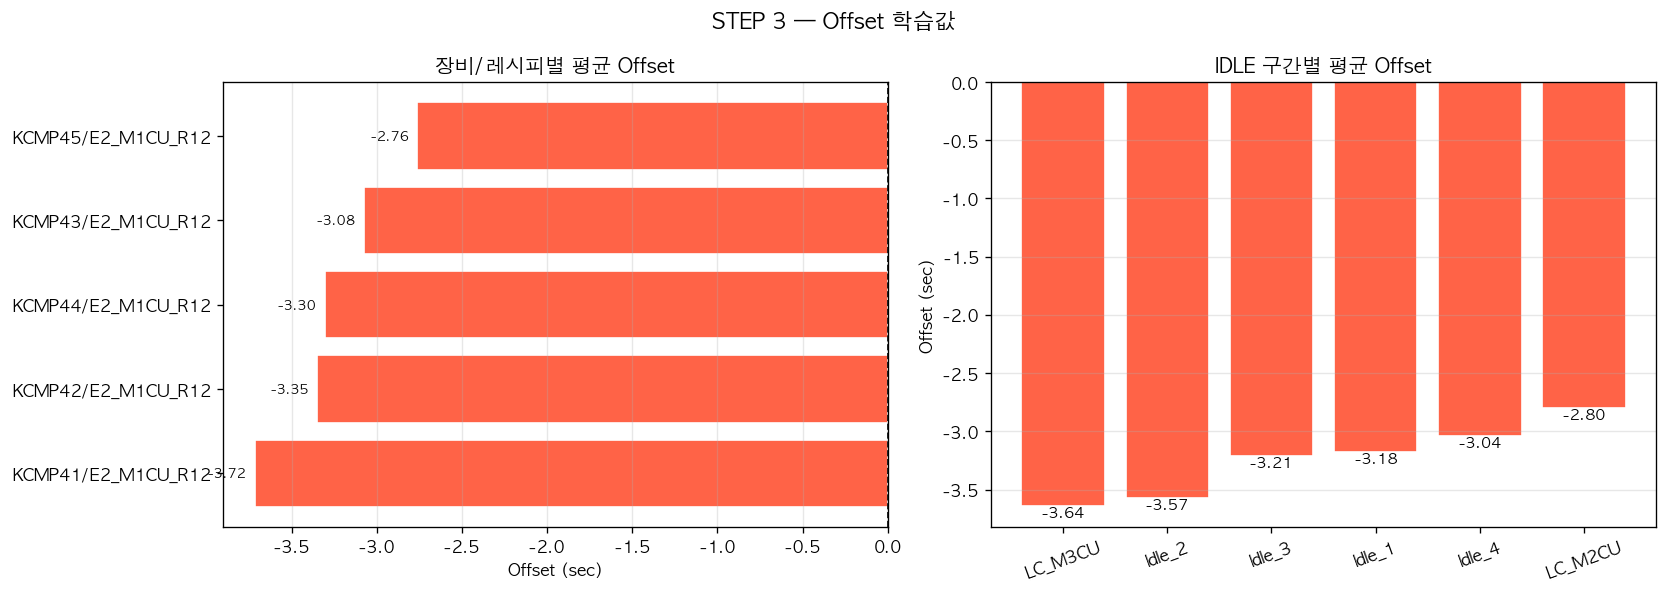

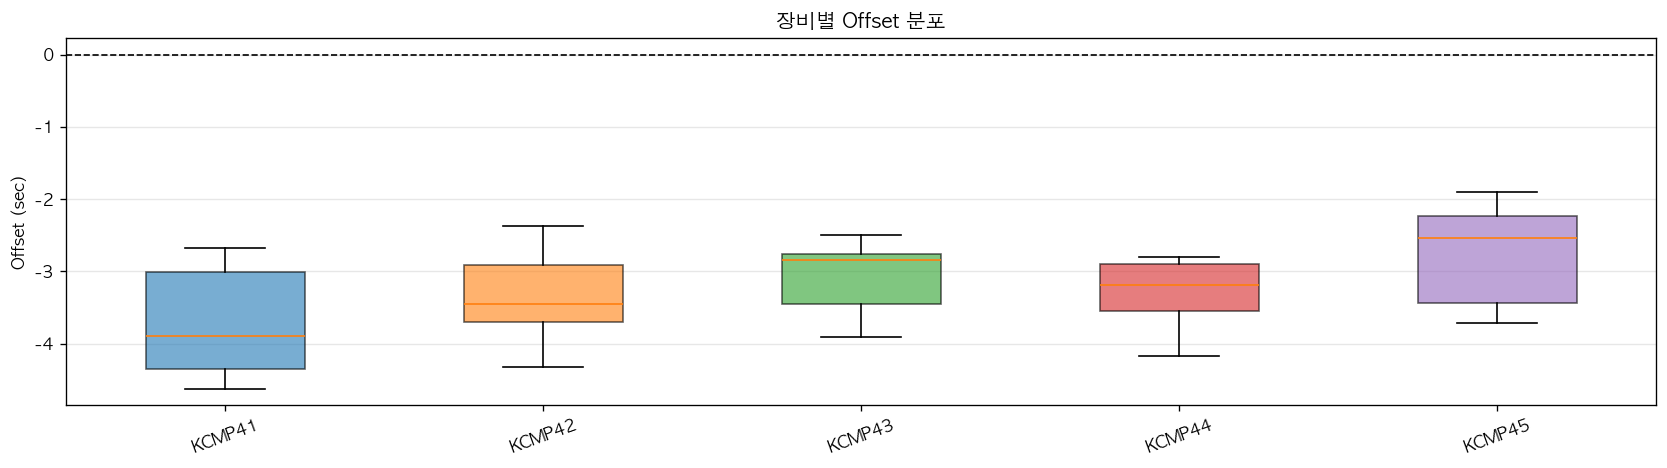


 Offset 통계
  평균  : -3.242 sec
  표준편차: 0.712 sec
  범위  : -4.624 ~ -1.906 sec


In [16]:
# ── Offset 시각화 ────────────────────────────────────────────────────
if not offset_df.empty and 'OFFSET' in offset_df.columns:

    offset_clean = offset_df.dropna(subset=['OFFSET']).copy()

    # eq_rcp 레이블 구성
    if 'eqp_id' in offset_clean.columns and 'recipe_id' in offset_clean.columns:
        offset_clean['eq_rcp'] = (
            offset_clean['eqp_id'] + '/' +
            offset_clean['recipe_id'].str.split('_').str[:3].str.join('_')
        )
    else:
        offset_clean['eq_rcp'] = 'Unknown'

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('STEP 3 — Offset 학습값', fontsize=13, fontweight='bold')

    # ① 장비/레시피별 평균 Offset (수평 bar)
    ax = axes[0]
    grp_o = offset_clean.groupby('eq_rcp')['OFFSET'].mean().sort_values()
    colors_bar_o = ['tomato' if v < 0 else 'steelblue' for v in grp_o]
    bars = ax.barh(grp_o.index, grp_o.values, color=colors_bar_o, edgecolor='white')
    ax.axvline(0, color='black', linewidth=1, linestyle='--')
    for bar, val in zip(bars, grp_o.values):
        pad_x = 0.05 if val >= 0 else -0.05
        ax.text(val + pad_x, bar.get_y() + bar.get_height() / 2,
                f'{val:.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8)
    ax.set_title('장비/레시피별 평균 Offset')
    ax.set_xlabel('Offset (sec)')
    ax.grid(axis='x', alpha=0.3)

    # ② IDLE 구분별 평균 Offset
    ax = axes[1]
    if 'IDLE' in offset_clean.columns:
        idle_grp = offset_clean.groupby('IDLE')['OFFSET'].mean().sort_values()
        colors_idle = ['tomato' if v < 0 else 'mediumseagreen' for v in idle_grp]
        bars = ax.bar(idle_grp.index.astype(str), idle_grp.values,
                      color=colors_idle, edgecolor='white')
        ax.bar_label(bars, fmt='%.2f', fontsize=9)
        ax.axhline(0, color='black', linewidth=1, linestyle='--')
        ax.set_title('IDLE 구간별 평균 Offset')
        ax.set_ylabel('Offset (sec)')
        ax.tick_params(axis='x', rotation=20)
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    # 장비별 Offset 분포 (boxplot)
    if 'eqp_id' in offset_clean.columns:
        fig, ax = plt.subplots(figsize=(14, 4))
        eqp_list_o = sorted(offset_clean['eqp_id'].unique())
        data_bp_o = [offset_clean[offset_clean['eqp_id'] == eq]['OFFSET'].values for eq in eqp_list_o]
        bp = ax.boxplot(data_bp_o, labels=eqp_list_o, patch_artist=True)
        colors_bp = plt.cm.tab10.colors
        for patch, color in zip(bp['boxes'], colors_bp):
            patch.set_facecolor(color)
            patch.set_alpha(0.6)
        ax.axhline(0, color='black', linewidth=1, linestyle='--')
        ax.set_title('장비별 Offset 분포', fontsize=12, fontweight='bold')
        ax.set_ylabel('Offset (sec)')
        ax.tick_params(axis='x', rotation=20)
        ax.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

    print(f'\n Offset 통계')
    print(f'  평균  : {offset_clean["OFFSET"].mean():.3f} sec')
    print(f'  표준편차: {offset_clean["OFFSET"].std():.3f} sec')
    print(f'  범위  : {offset_clean["OFFSET"].min():.3f} ~ {offset_clean["OFFSET"].max():.3f} sec')

else:
    print('시각화할 Offset 데이터 없음 — 위 셀들을 순서대로 실행하세요.')

---
## STEP 4 — Alarm 점검

Pre_Thk_VM / RR / Offset 학습값을 이전 실적 대비 N-Sigma 기준으로 점검합니다.  
로컬 환경에서는 MongoDB가 Mock이므로 이전 실적이 없어 알람은 발생하지 않습니다.

In [17]:
# ── Alarm 점검 실행 ─────────────────────────────────────────────────
for key_str in mico_info_table['for_key_list'].unique():
    mico_key = mico_info_table[mico_info_table['for_key_list'] == key_str].copy()
    Module_Get.check_alarm(mico_key)


  [Alarm 점검] M10 | LC | M1 CU CMP 시작
    DB 로드: Pre_Thk_VM=0건 | Removal Rate=0건 | Offset=0건
    RR 데이터 없음 → 알람 점검 스킵
  [Alarm 점검] M10 | LC | M1 CU CMP 완료


---
## 전체 파이프라인 한 번에 실행

위 단계(STEP 1~4)를 모두 한 번에 실행하고 싶을 때 사용합니다.

In [18]:
RUN_ALL = False   # ← True 로 바꾸면 전체 파이프라인 실행

if RUN_ALL:
    from Common.Module import run
    _STORE.clear()
    run(FAMILY, OPER_DESC, POL_TYPE)
    print('\n✅ 전체 파이프라인 완료 — 위의 각 시각화 셀을 다시 실행하세요.')

---
## 결과 저장소 확인

`_STORE`에 저장된 모든 컬렉션 목록과 건수를 확인합니다.

In [19]:
print('_STORE 컬렉션 목록')
print('=' * 60)
for k, v in _STORE.items():
    print(f'  {k}: {len(v)}건')
    if v:
        df_tmp = pd.DataFrame(v)
        print(f'    컬럼: {df_tmp.columns.tolist()}')

_STORE 컬렉션 목록
  MICO_PRE_THK_LC_M1 CU CMP_M10_Period: 16건
    컬럼: ['pre_oper_time', 'pre_eq_ch', 'Pre_Thk', 'Count', 'THK_Para', 'Date', 'Oper_Code']
  MICO_Removal_Rate_LC_M1 CU CMP_M10: 5건
    컬럼: ['Date', 'Fab', 'Lot_Code', 'Oper_Code', 'Oper_Desc', 'APC_Para', 'EQ', 'Recipe_ID', 'Count', 'b1', 'b0', 'b1_weighted', 'b0_weighted', 'if_b1', 'if_b0']
  MICO_OFFSET_LC_M1 CU CMP_M10: 30건
    컬럼: ['eqp_id', 'recipe_id', 'IDLE', 'OFFSET', 'APC_Para', 'Date']
